In [88]:
#import packages
import time
import numpy as np
from typing import *
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import plotly.graph_objects as go
from scipy.interpolate import splprep, splev
import csv
import os
from NIDAQ import USB6363
import nidaqmx
from nidaqmx.constants import AcquisitionType
from nidaqmx.constants import Edge
from src.DieTesterInstrument import *
from src.FirstLightController import *
from src.ChipAlignmentController import ChipAlignmentController
from src.NIDAQPowermeter import PowermeterSystem
from src.SoftwareFence import SoftwareFence
import SantecTunableLaser
print(dir(SantecTunableLaser))
#list ASRLs
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources(query ='?*') # to make sure all the Suruga stages are connected

['TSL', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'pyvisa', 'time']


('USB0::0x0957::0x3718::MY51350815::0::INSTR',
 'ASRL9::INSTR',
 'ASRL11::INSTR',
 'ASRL8::INSTR',
 'ASRL10::INSTR',
 'TCPIP0::10.101.0.157::64000::SOCKET',
 'TCPIP0::K-EXR608A-60117::hislip0::INSTR',
 'TCPIP0::K-EXR608A-60117::inst0::INSTR',
 'TCPIP0::K-EXR608A-60117::5025::SOCKET',
 'TCPIP0::K-N7749C-00104::inst0::INSTR',
 'TCPIP0::K-N7749C-00104::5025::SOCKET',
 'TCPIP0::K-N7749C-00104::hislip0::INSTR',
 'TCPIP0::K-N7786C-00222::inst0::INSTR',
 'TCPIP0::K-N7786C-00222::5025::SOCKET',
 'TCPIP0::K-N7786C-00222::hislip0::INSTR',
 'TCPIP0::K-N7742C-00112::inst0::INSTR',
 'TCPIP0::K-N7742C-00112::5025::SOCKET',
 'TCPIP0::K-N7742C-00112::hislip0::INSTR',
 'TCPIP0::K-N7776C-00505::inst0::INSTR',
 'TCPIP0::K-N7776C-00505::5025::SOCKET',
 'TCPIP0::K-N7776C-00505::hislip0::INSTR',
 'ASRL1::INSTR',
 'ASRL3::INSTR')

In [91]:
#@ Die Tester Stage and Powermeter + Motion I/O

try:
    stg.close()
    pm.close()
    time.sleep(1)
    del stg
    del pm
except:
    0

stg = DieTesterStage(9, 11, 8, 10)
# stg = DieTesterStage(19, 20, 21, 22) # before moving: 13, 15, 5, 4
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) # needs Dev1 for the raster to work

Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


In [92]:
# testing USB connection
TSL770 = SantecTunableLaser.TSL('TCPIP0::10.101.0.157::64000::SOCKET') # LAN
TSL770.timeout = 5000

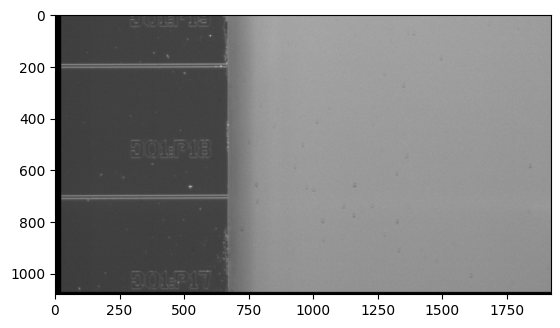

In [93]:
## OBS Virtual Camera (Make sure its on and that you have the correct name)
%matplotlib inline
def clear_interface():
    plt.close('all')
    clear_output(wait=True)

cap = RealtimeVideoCapture(1)  # Change to whatever index your OBS camera is. 
time.sleep(1)

clear_interface()
plt.imshow(cap.mean_capture(10, convert_to_grayscale=False))
plt.show()

In [94]:
flc = FirstLightController(pm, stg)
cac = ChipAlignmentController(stg, cap)
fence = SoftwareFence(stg, cap)

### Manually align the fibers in x, y and z
Move fibers to a safe location

In [ ]:
# MANUALLY ALIGN THE FIBERS, TO DO THIS: raise the fibers, bring it closer, 
# change x to bring the fibers into field of view of camera, move back the fiber and bring it 
# down into the focus of camera
# MOVE FIBERS BACK TO A SAFE LOCATION
## Enter whatever commands you need to do this
stg.set_speed('r', 9)
stage = 'l'
stg.move_relative(stage, 'z', -500, wait=True)

In [6]:
stage = 'r'
stg.move_relative(stage, 'z', -1000, wait=True)

# # Save safe positions (or at least print them out).
# l_safe_position = stg.query_position('l')
# print(l_safe_position)
# r_safe_position = stg.query_position('r')
# print(r_safe_position)

### CHIP ALIGNMENT

In [ ]:
# CHIP ALIGNMENT
## Move chip (and camera) so that the top or bottom calibration patterns are visible in the camera, roughly in the middle.
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -9000, wait=True)# -9000 or 9000 to move it

In [ ]:
## Run to open template selection widget and draw a bounding box around the pattern or alignment mark.
%matplotlib widget

img = cap.mean_capture(20)
clear_interface()
cac.new_template_selection(img)

In [ ]:
## Save the template to the alignment controller
%matplotlib inline

template_image = cac.generate_template(img)
clear_interface()
plt.imshow(template_image)
plt.scatter(template_image.shape[1] / 2, template_image.shape[0] / 2, c='r')
plt.show()

In [478]:
# move the chip to see the other alignment mark and bring it back
stg.set_speed('m', 9)
stg.move_relative('m', 'X', 381, wait=True)# -10000 or 10000, TFLN 9000, b/w adjacent wvgs 6 um; wvg sets 381um
#remember to move it back and not to redefine the template

In [ ]:
%matplotlib inline
## Select your movement values and perform chip alignment.
# Large movement should be roughly the length of the chip (1 cm works well), small calibration movement should be a few hundred microns.
#   - Make sure that the small movement doesn't bring your calibration pattern out of frame
# The sign of the movements should be positive for moving from top to bottom, and negative for moving bottom to top.


mainX = 9_000  # main movement (width of chip), 10_000 original
calX = 500  # calibration movement, 500 before
deg = cac.run_angle_calibration(mainX, calX, camera_focus_prompt=True) 

In [ ]:
## If angle seems reasonable, rotate to align chip
# Check the pattern centers in the images for reasonableness
stg.move_relative_rotation(deg) # deg

### COARSE FIBER ALIGNMENT MANUALLY

In [145]:
## Perform this for both the left and right stages. ('l' and 'r')
stage = 'l'
## Do whatever commands you need to move the left/right fiber into the frame and in focus.
stg.move_relative(stage, 'z', -1, wait=True)#moved 40, -30
# change the height of fibers manually using a fault detector to see light through the waveguide
#for both left and right

FIRST LIGHT

In [146]:
import importlib
import src.FirstLightController
importlib.reload(src.FirstLightController)
from src.FirstLightController import *

flc = FirstLightController(pm, stg)

In [148]:
# Initialize switch
# address = 'TCPIP0::10.101.0.199::5025::INSTR' # N7731A
address = 'USB0::0x0957::0x3718::MY51350815::INSTR' # N7731A
# address = 'USB0::0x0957::0x3718::MY51350266::INSTR' # N7734A 
# USB0::0x0957::0x3718::MY51350815::0::INSTR

rm = pyvisa.ResourceManager()
switch = rm.open_resource(address)
switch.timeout = 5000 

# Verify Connection to the switch
idn = switch.query('*IDN?')
print(f"Connected to: {idn}")

Connected to: Keysight Technologies, N7731A, MY51350815, 1.21



##### Move the fibers ~ 2 um away from the chip

In [211]:
stg.move_relative('r', 'z', -1000, wait=True)

In [212]:
stg.move_relative('l', 'z', -1000, wait=True)

##### Helper functions

In [149]:
# Convert NewFocus PD output voltage to power 
def pdToPow(x, g): # argument x is the photodiode output volts from tap
    # g is the gain setting
    R = 0.55 # responsivity, can interpolate the graph for more accurate values
    tap_pow = x/(g*R) # power in mW
    #act_pow = tap_pow*10*0.9*0.5 # 90/10 and 50/50 splitter output
    return tap_pow # in mW

def logPDtoPow(Vout):
    Vy = 0.3
    Iz = 100e-12
    Ipd = Iz * 10**(Vout/Vy)
    R = 0.9
    pow = Ipd/R
    return pow*1e3

def switch_route(route_no, output_port):
    switch.write('rout' + route_no + ':chan1 A,' + output_port)

def gaussian_fit_func(xy, a, x0, sigxsq, y0, sigysq):
    x = xy[:,0]
    y = xy[:,1]
    return a * np.exp(-((x-x0)**2/sigxsq + (y-y0)**2/sigysq))

def raster_fit(datapoints):

    xy_points = datapoints[:, 0:2]
    P_points = datapoints[:, 2]

    # fitting a 2d gaussian
    p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

    [fitparams, fitcov] = curve_fit(gaussian_fit_func, xy_points, P_points, p0, maxfev=5000)
    fitcov
    fit_gauss = gaussian_fit_func(xy_points, *fitparams)

    # fig = go.Figure()
    # fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=P_points,
    #                                 mode='markers', marker=dict(
    #                 size=2,          # Marker size in pixels
    #                 color='blue',      # Marker color
    #                 opacity=0.8,      # Transparency
    #                 symbol='circle'   # Marker shape
    #             )))
    # fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=fit_gauss, marker=dict(
    #                 size=2,          # Marker size in pixels
    #                 color='red',      # Marker color
    #                 opacity=0.8,      # Transparency
    #                 symbol='circle'   # Marker shape
    #             )))
    # fig.show()

    x0 = fitparams[1]
    y0 = fitparams[3]

    if np.abs(x0) > 3.5 or np.abs(y0) > 7: # for safety if the fit is wrong
        x0 = y0 = 0
    
    print(f"Moved to {[x0, y0]}")
    print('Max is: ', np.max(P_points))
    return x0, y0

def raster_scan(stage, broad_range):
    line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
    speed = 7# 7  

    if broad_range == True:
        commands = flc.pgen.generate_linear_spiral((10, 10), 20)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
    else:
        commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
    result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

    datapoints = result['datapoints']
    return datapoints

def parabola(x, a, b, c):
    return a*x + b* x**2 + c

def z_scan(stage, broad_range):
    if broad_range == True:
        commands = [
        ['Z', 2],#2
        ['Z', -4], #-8
        ]
    else:
        commands = [
        ['Z', 1],#2
        ['Z', -2], #-8
        ]
        
    line_numbers = [0, 1, 2] # left XY, right XY, all Z
    speed = 6 # increased speed from 2

    result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

    datapoints = result['datapoints']

    z_tun = datapoints[:,0]
    Pz_tun = datapoints[:,2]

    # fig = plt.figure('z_scan')
    # ax = fig.add_subplot(111)
    # plt.plot(z_tun, Pz_tun, 'o') # plotting for checking, remove in a loop
    
    # tck, u = splprep([z_tun, Pz_tun], s=40, k = 5)
    # new_points = splev(u, tck)
    # plt.plot(new_points[0], new_points[1])
    # # fig.show()
    
    # print(new_points[0][np.argmax(new_points[1])])

    # stg.move_relative(stage, 'z', new_points[0][np.argmax(new_points[1])], wait=True)

    # return new_points[0][np.argmax(new_points[1])]

    [fitparams, fitcov] = curve_fit(parabola, z_tun, Pz_tun) # p0
    fitcov
    fit_par = parabola(z_tun, *fitparams)

    # plt.plot(z_tun, fit_par)plotting for checking, remove in a loop
    print(z_tun[np.argmax(fit_par)])

    return z_tun[np.argmax(fit_par)]

def fine_tun():
    z_trans_l = z_scan('l', True) # False?
    # time.sleep(0.75)
    stg.move_relative('l', 'Z', z_trans_l)
    stage = 'l'
    raster_data = raster_scan(stage, False)
    x0, y0 = raster_fit(raster_data)
    stg.move_relative(stage, 'X', x0)
    stg.move_relative(stage, 'Y', y0)

    z_trans_r = z_scan('r', True)# False?
    # time.sleep(0.75)
    stg.move_relative('l', 'Z', z_trans_r)
    stage = 'r'
    raster_data = raster_scan(stage, False)
    x0, y0 = raster_fit(raster_data)
    stg.move_relative(stage, 'X', x0)
    stg.move_relative(stage, 'Y', y0)

    return raster_data, z_trans_l, z_trans_r

def prep_next_wvg(z_trans_l, z_trans_r, device_no):
    stg.move_relative('l', 'z', -z_trans_l, wait=True)
    stg.move_relative('r', 'z', -z_trans_r, wait=True)

    # # move the chip to the next waveguide set
    stg.set_speed('m', 9)
    stg.move_relative('m', 'X', -381, wait=True) # assuming both will be damaged?

    device_no+=1
    return device_no

### Defining file path and name to store data

In [151]:
folder_path = "C:/Users/Pooja/Documents/Pooja/OneDrive - NTT Research Inc/Documents/Die testing/Insertion_loss_transfer_function/TFLN08_SCG-1/"
chip_no = input("Enter chip number: ").strip()
folder_name = f"chip{chip_no}"
device_no = int(input("Enter device number: ").strip())
wvg_set = input("Enter the upper or lower wvg set: ").strip()

folder_path = folder_path + folder_name

# Create directories if they don't exist
os.makedirs(folder_path, exist_ok=True)

file_path = os.path.join(folder_path, "insertion_loss2.csv")

with open(file_path, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Device no", "Waveguide set", "IL (dB)"])

### function for measuring and saving transfer function 

In [152]:
header = r'Tapvolt770(V),SHGvoltage(V),Trigger volt(V), Wavelength(um)'
def transfer_fn(folder_path, device_no, wvg_set):
    # ACTUAL TWM setup; continuous sweeping
    start_wavelength = 1500e-9
    stop_wavelength = 1620e-9
    sample_rate = 10000
    sweep_speed = 200  # nm/s - useful for 30 us, 200 ACTUAL
    sweep_range = stop_wavelength - start_wavelength
    sweep_time = sweep_range * 1e9 / sweep_speed  # seconds, factor of 1.5 given in the old code, required?
    n770 = int(sweep_time * sample_rate)
    samples = np.arange(n770)

    steps_770 = np.linspace(start_wavelength, stop_wavelength, n770)
    trigger_step = 100e-12

        # Configure TSL770 for sweeping

    TSL770.wavelength_start(start_wavelength)
    TSL770.wavelength_stop(stop_wavelength)

    # Note: trigger_step caps sweep speed; always set it first
    # TSL770.trigger_step(4e-12) # useful for 10 nm/s
    # TSL770.trigger_step(20e-12) # useful for 100 nm/s
    TSL770.trigger_step(trigger_step) # useful for 200 nm/s
    TSL770.sweep_speed(sweep_speed)
    TSL770.trigger_setting(1) # 1 - Time trigger; nonuniform wvl spacing, 0 - wavelength trigger
    TSL770.sweep_mode(1) # continuous sweep

    # Configure DAQ

    # # Add Digital input channels
    # daq.di_task = nidaqmx.Task()
    # daq.di_task.di_channels.add_di_chan("Dev2/Port1/Line5")
    daq.ai_task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source = "/Dev2/PFI5", trigger_edge=Edge.RISING)

    t_samp_daq = 1/sample_rate
    t_samp_770 = trigger_step * 1e9/sweep_speed
    daq.configure_sampling(sample_rate, n770)
    TSL770.wavelength(start_wavelength)

    time.sleep(0.6)  # Allow lasers to settle
    # print(f'570: {step_570 * 1e9:.2f} nm')

    # Measure data

    TSL770.sweep_state(1)
    daq.start()
    data = daq.read()
    daq.stop()

    raw_wavelength_data = TSL770.read_wavelength()
    t_daq = t_samp_daq * samples
    t_770 = t_samp_770 * np.arange(len(raw_wavelength_data))
    steps_770 = np.interp(t_daq, t_770, raw_wavelength_data)
    # print(data)
    # pout[i, :] = data[0][0]      # power
    # tap_570[i, :] = data[0][1]   # 570 tap
    # tap_770[i, :] = data[0][2]   # 770 tap
    # trigger_diagnostic[i, :] = data[0][3] 

    time.sleep(0.6)

    folder_name = folder_path + '/Transfer_function/'

    plt.plot(steps_770, np.array(data[0][1])) # in daq configured sampling, /(3e4 * 0.45)
    plt.xlabel(r'Wavelength ($\mu$m)')
    # plt.ylabel('SHG power (mW)')
    plt.ylabel('PD output voltage (V)')
    plt.savefig(folder_name + str(device_no) + wvg_set +'.png')

    dataT = np.reshape(data, (3, len(steps_770))).T
    data_new = np.column_stack((dataT, steps_770))
    np.savetxt(folder_name + str(device_no) + wvg_set + 'ver2.csv', data_new, delimiter = ',', header = header)

In [153]:
z_trans_r = z_trans_l = 2 # 50
# z_trans_r

In [154]:
# Interpolate to get the power in mW after the lensed fiber for a given tap output
# tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut770_aftBOA267mA.csv", delimiter = ',', skiprows= 1)
tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut_aftBOA267mA_aftLensedFiber.csv", delimiter = ',', skiprows= 1)

idx = np.argmin(np.abs(tap_data[:,0] - 1.56e-6))
inp_pow = tap_data[idx,2]*1e3 # scaling

#### One waveguide at a time

In [206]:
'''
Aligning at 1560 nm

'''

# device_no = 18
threshold = 0.02

# Broad scan, femto detector
switch_route('1', '1')
ai_channel = 'ai0'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

stage = 'r'
raster_data = raster_scan(stage, True)# actual true
if np.max(raster_data[:,2]) < threshold:
    x0, y0 = 0, 0
                # # move fibers back
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
else:
    x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0, wait=True)
stg.move_relative(stage, 'Y', y0, wait=True)

stage = 'l'
raster_data = raster_scan(stage, True)
x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0, wait=True)
stg.move_relative(stage, 'Y', y0, wait=True)

# Small scan, log detector
switch_route('1', '2')
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

# increasing z scan speed, don't need sleep anymore
z_trans = z_scan('l', True) 
stg.move_relative('l', 'Z', z_trans)
# z_trans_l= z_trans_l - 2 + z_trans
z_trans_l= z_trans
stage = 'l'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0
# --- Optionally save None or NaN for this waveguide ---
stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

z_trans = z_scan('r', True)
stg.move_relative('r', 'Z', z_trans)
# z_trans_r = z_trans_r - 2 + z_trans
z_trans_r= z_trans
stage = 'r'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

# fine_tun_data = fine_tun()
# raster_data = fine_tun_data[0]
# z_trans_l+= fine_tun_data[1]
# z_trans_r+= fine_tun_data[2]

il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow) # in dB, cross-check PD gain value
print('Insertion loss- ', il)

# not including Si PD raster scan if the second harmonic power is too low

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.48item/s]


Returning to original position...
Moved to [np.float64(0.10359215354611787), np.float64(-0.05946563802629039)]
Max is:  2.0873843917963697
Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.71item/s]


Returning to original position...
Moved to [np.float64(-0.00916945410380648), np.float64(0.20251839118694015)]
Max is:  1.964618288864889
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


...

Returning to original position...
Moved to [np.float64(0.12852050664795747), np.float64(0.2881877364853042)]
Max is:  1.9605958100012804
Starting motion...


Current Move: (Z, -4.0): 100%|██████████| 2/2 [00:00<00:00,  5.10item/s]


Returning to original position...
-1.9999999999999996
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.06item/s]


Returning to original position...
Moved to [np.float64(0.1255175555295386), np.float64(-0.15220426737921128)]
Max is:  1.9401616188827633
Insertion loss-  -18.113195684611398


### Save IL data

In [207]:
with open(file_path, mode="a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([device_no, wvg_set, il])

### Optimize for 780 nm

In [208]:
# Do raster scan in Si PD if the SHG power is high
# Si PD
switch_route('1', '3')
ai_channel = 'ai2'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

stage = 'r'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

stage = 'l'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

AIChannel(name=Dev1/ai2)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.25item/s]


Returning to original position...
Moved to [np.float64(-0.15497261328142597), np.float64(0.05409539322950759)]
Max is:  1.31313876694635
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.46item/s]


Returning to original position...
Moved to [np.float64(0.01324252059453318), np.float64(-0.14549624058179664)]
Max is:  1.455694982953177


In [203]:
# change to Si PD before TWM
switch_route('1', '3')
ai_channel = 'ai2'

### Initialize daq, do transfer function measureemnt and save

Connected to: NI DAQ, Dev2, USB-6363 (BNC)
200


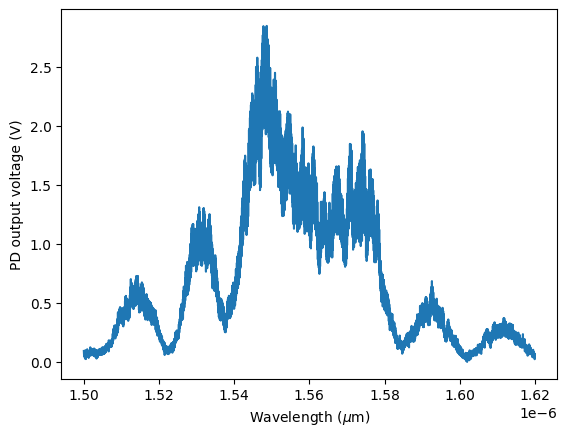

In [209]:
daq = USB6363()
# Add Analog input channels, 4 - Si, 5 - TSL770
daq.ai_task = nidaqmx.Task()
daq.ai_task.ai_channels.add_ai_voltage_chan("Dev2/ai5, Dev2/ai4, Dev2/ai0")

transfer_fn(folder_path, device_no, wvg_set)

daq.close()

In [210]:
TSL770.wavelength(1560e-9)
time.sleep(0.5)

### Move back fibers and go to the next waveguide

In [196]:

#cMove back the fibers and go to the next waveguide
# made z_trans_l = z_trans_r = 2
if (z_trans_l > 1):
    stg.move_relative('l', 'z', -z_trans_l, wait=True)
else:
    z_trans_l = 2
    stg.move_relative('l', 'z', -z_trans_l, wait=True)

if z_trans_r > 1:
    stg.move_relative('r', 'z', -z_trans_r, wait=True)
else:
    z_trans_r = 2
    stg.move_relative('r', 'z', -z_trans_r, wait=True)

# # move the chip to the next waveguide
stg.set_speed('m', 9)
gap = 8
if gap < 9:
    stg.move_relative('m', 'X', (8), wait=True) 
    wvg_set = 'l'
else:
    stg.move_relative('m', 'X', (381), wait=True) 
    device_no-=1
    wvg_set = 'u'

### Once the data is all saved, close file

In [38]:
f.close()

In [ ]:
TSL770.close()

### Just previous codes, not required from now on

In [22]:
z_trans_l

np.float64(-0.8997668997668997)

In [102]:
# Interpolate to get the power in mW after the lensed fiber for a given tap output
# tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut770_aftBOA267mA.csv", delimiter = ',', skiprows= 1)
tap_data = np.loadtxt(r"c:\Users\Pooja\Documents\GitHub\Three-wave-mixing\characterization_data\lut_aftBOA267mA_aftLensedFiber.csv", delimiter = ',', skiprows= 1)

idx = np.argmin(np.abs(tap_data[:,0] - 1.56e-6))
inp_pow = tap_data[idx,2]*1e3 # scaling
# print('Insertion loss- ', 10*np.log10(pdToPow(np.max(datapoints[:,2]), 10)/inp_pow)) # 32
il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow)
print('Insertion loss- ', il) # 32

Insertion loss-  25.646211170213135


#### To do all the waveguides in a chip in one go

In [ ]:
 UPDATED - LATEST
# All waveguides in one go starting from device 1

device_no = 1
threshold = 0.02

folder_path = "C:/Users/Pooja/Documents/Pooja/OneDrive - NTT Research Inc/Documents/Die testing/Insertion_loss_transfer_function/TFLN08_SCG-1/"
# folder_path = "c:/Users/Lab1.6.NTTR-JB7LY33/Documents/Pooja/TFLN08_SCG-1/"
chip_no = 'Chip43'
folder_path = folder_path + chip_no
file_path = os.path.join(folder_path, "insertion_loss.csv")

# Create directories if they don't exist
os.makedirs(folder_path, exist_ok=True)
# filename = "Notes/insertion_loss_device43.csv"

with open(file_path, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Device no", "IL (dB)"])

    for i in range(42):

        # Broad scan, femto detector
        switch_route('1', '1')
        ai_channel = 'ai0'
        pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
        flc = FirstLightController(pm, stg) 

        stage = 'l'
        raster_data = raster_scan(stage, True)# actual true
        if np.max(raster_data[:,2]) < threshold:
            print(f"Skipping damaged waveguide: {i}")
                        # # move fibers back
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
            continue  # Jumps to the next waveguide in the list
        
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration
        
        stg.move_relative(stage, 'X', x0, wait=True)
        stg.move_relative(stage, 'Y', y0, wait=True)

        stage = 'r'
        raster_data = raster_scan(stage, True)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration

        stg.move_relative(stage, 'X', x0, wait=True)
        stg.move_relative(stage, 'Y', y0, wait=True)

        # Small scan, log detector
        switch_route('1', '2')
        ai_channel = 'ai1'
        pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
        flc = FirstLightController(pm, stg) 

        # increasing z scan speed, don't need sleep anymore
        z_trans = z_scan('l', True) 
        # time.sleep(0.75)
        stg.move_relative('l', 'Z', z_trans)
        z_trans_l= z_trans
        stage = 'l'
        raster_data = raster_scan(stage, False)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration

        stg.move_relative(stage, 'X', x0)
        stg.move_relative(stage, 'Y', y0)

        z_trans = z_scan('r', True)
        # time.sleep(0.75)
        stg.move_relative('r', 'Z', z_trans)
        z_trans_r = z_trans
        stage = 'r'
        raster_data = raster_scan(stage, False)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration
        
        stg.move_relative(stage, 'X', x0)
        stg.move_relative(stage, 'Y', y0)

        # fine_tun_data = fine_tun()
        # raster_data = fine_tun_data[0]
        # z_trans_l+= fine_tun_data[1]
        # z_trans_r+= fine_tun_data[2]

        il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow) # in dB, cross-check PD gain value
        print('Insertion loss- ', il)
        

        # writer.writerow([device_no, il]) # i for device no

       #cMove back the fibers and go to the next waveguide
        # made z_trans_l = z_trans_r = 2
        if z_trans_l > 1:
            stg.move_relative('l', 'z', -z_trans_l, wait=True)
        else:
            z_trans_l = 2
            stg.move_relative('l', 'z', -z_trans_l, wait=True)

        if z_trans_r > 1:
            stg.move_relative('r', 'z', -z_trans_r, wait=True)
        else:
            z_trans_r = 2
            stg.move_relative('r', 'z', -z_trans_r, wait=True)

        if i%2 == 0:
            writer.writerow([str(device_no) + 'lower', il]) # i for device no
            stg.set_speed('m', 9)
            stg.move_relative('m', 'X', -8, wait=True)
            # # move the chip to the next waveguide
        else:
            writer.writerow([str(device_no) + 'upper', il]) # i for device no
            stg.set_speed('m', 9)
            stg.move_relative('m', 'X', -(381 - 8), wait=True)
            device_no+=1

        if device_no == 21 and i%2!=0:
            break

        


    

#### previous versions

In [168]:
route_no = '1'# For two channels rout1 or rout2
output_port = '1'

switch.write('rout' + route_no + ':chan1 A,' + output_port)

17

In [552]:
switch.close()

#### convert SHG voltages to power

In [ ]:
gain = 3e4
R = 0.45 # V/mW
shg_pow = shg_v/(gain * R)

# calculating conversion efficiency
pf = inp_pow*1e-3 * 10**-0.75 # IL approx 15 dB throughput
pshg = 2.296e-9/10**-0.75
l = 6e-3
pshg/(pf**2 * l**2) * 100 # in %

In [169]:
ai_channel = 'ai0'#, 'ai3', 'ai4', 'ai5']
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg)

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


In [192]:
### Broad scan, can make it small scan with generate_linear_spiral((5, 5), 10)
stage = 'l'
line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
speed = 7# 7                  # Speed setting from 0-9. Higher is only faster to a point.
# ai_channel = 'ai1'

broad_range = False
if broad_range == True:
    commands = flc.pgen.generate_linear_spiral((20, 20), 40)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
else:
    commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
# commands = flc.pgen.generate_linear_spiral((10, 10), 20)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = True)

datapoints = result['datapoints']

# Not plotting the distribution
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]
print(f"Maximum: {max_point}")

fig.show()

Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:02<00:00,  6.68item/s]


Returning to original position...
Fitting gaussian regression to datapoints...
Found optimal parameters.
Mean: [ 0.01229023 -0.00249438]
Cov: [[1.24491486 0.76423156]
 [0.76423156 3.05640638]]
Maximum: [ 0.29032258 -1.        ]


In [165]:
datapoints.shape

(38171, 3)

In [193]:
# Move to the gaussian fit mean

mean = result['mean']
stg.move_relative(stage, 'X', mean[0])#mean[0])
stg.move_relative(stage, 'Y', mean[1])#mean[1])
print(f"Moved to {mean}")

Moved to [ 0.01229023 -0.00249438]


In [561]:
# Move to maximum slop 

xy = datapoints[:, 0:2]
Int = datapoints[:, 2]

x = xy[:, 0]
y = xy[:, 1]

x_unique = np.unique(x)
y_unique = np.unique(y)

nx = len(x_unique)
ny = len(y_unique)

grid = np.zeros((ny, nx))

x_index = {v: i for i, v in enumerate(x_unique)}
y_index = {v: i for i, v in enumerate(y_unique)}

for i in range(len(Int)):
    xi = x[i]
    yi = y[i]
    grid[y_index[yi], x_index[xi]] = Int[i]

dP_dy, dP_dx = np.gradient(grid, y_unique, x_unique)

grad_mag = np.sqrt(dP_dx**2 + dP_dy**2)

imax = np.unravel_index(np.argmax(grad_mag), grad_mag.shape)

x_pos,y_pos = x_unique[imax[1]] , y_unique[imax[0]]

stg.move_relative(stage, 'X', x_unique[imax[1]])
stg.move_relative(stage, 'Y', y_unique[imax[0]])

print('Moved to ',(x_pos,y_pos))


Moved to  (np.float64(0.2), np.float64(0.5))


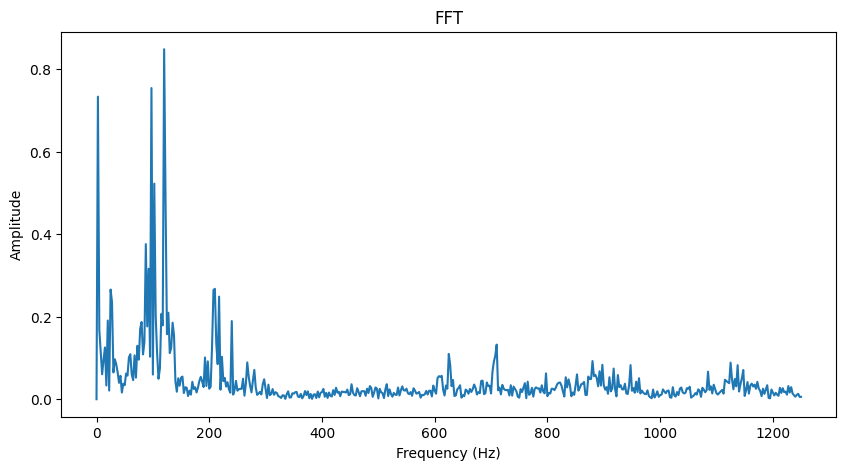

In [563]:
#Collecting Data + FFT 
N = 1000  #Sample points
fs = 2500 #Sample rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan("Dev1/ai1")
    task.timing.cfg_samp_clk_timing(fs, sample_mode=AcquisitionType.FINITE, samps_per_chan=N)
    data = task.read(number_of_samples_per_channel=N)

data = np.array(data)
data -= np.mean(data)
fft = np.fft.rfft(data)
freq = np.fft.rfftfreq(N, 1/fs)

plt.figure(figsize=(10,5))
plt.plot(freq, np.abs(fft))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
# plt.xlim(50,200)
# plt.ylim(0,1)
plt.title("FFT")
plt.show()

In [188]:
## Z fine-tuning
stage = 'l'
line_numbers = [0, 1, 2] # left XY, right XY, all Z
speed = 6

# Enter a list of relative commands manually, comes back to original position
commands = [
    ['Z', 1],#2
    ['Z', -3], #-8
]
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]

fig.show()

Starting motion...


Current Move: (Z, -3.0): 100%|██████████| 2/2 [00:00<00:00,  6.68item/s]


Returning to original position...


-0.16991643454039007


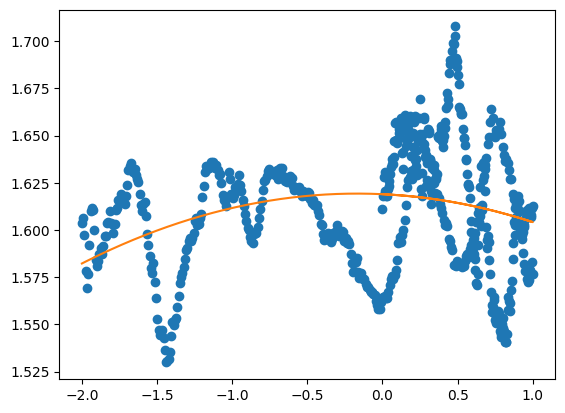

In [189]:
# do the same raster scan for 'r'
z_tun = datapoints[:,0]
Pz_tun = datapoints[:,2]

plt.plot(z_tun, Pz_tun, 'o')

def parabola(x, a, b, c):
    return a*x + b* x**2 + c

# fitting a 2d gaussian
# p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

[fitparams, fitcov] = curve_fit(parabola, z_tun, Pz_tun) # p0
fitcov
fit_par = parabola(z_tun, *fitparams)

plt.plot(z_tun, fit_par)
print(z_tun[np.argmax(fit_par)])
stg.move_relative(stage, 'Z', z_tun[np.argmax(fit_par)])

Maybe even close to 20% fluctuations. from the fiber?

In [126]:
# Moved to [np.float64(-883.8322536776053), np.float64(-70.33244976197754)]
stage = 'l'
stage
# move fibers front initially
stg.move_relative(stage, 'z', -1000, wait=True)

In [51]:
# # move the chip to the next waveguide
stg.set_speed('m', 9)
stg.move_relative('m', 'X', (-8), wait=True) #381